# Coursera Course Dataset Analysis

## Phase 2: Data Cleaning

This notebook analyzes the Coursera Course Dataset from Kaggle. In this phase, the goal is to make the raw dataset reliable before we begin exploratory data analysis.

Data cleaning means checking whether the columns, values, and data types are suitable for analysis. If the data has an old index column, text values that should be numbers, duplicate rows, or inconsistent categories, we fix or document those issues before answering business questions.

## Dataset Description

- Source: Kaggle Coursera Course Dataset
- Raw file used in this project: `../data/coursea_data.csv`
- Each row represents one Coursera course or course-related offering.
- Main columns include course title, course organization, certificate type, rating, difficulty level, and students enrolled.

We will first load the data and inspect its basic structure.

In [1]:
from pathlib import Path

import pandas as pd

DATA_PATH = Path("../data/coursea_data.csv")
CLEANED_OUTPUT_PATH = Path("../outputs/coursera_courses_cleaned.csv")

raw_courses = pd.read_csv(DATA_PATH)

raw_courses.head()

,Unnamed: 0,course_title,course_organization,course_Certificate_type,course_rating,course_difficulty,course_students_enrolled
0,134,(ISC)² Systems Security Certified Practitioner...,(ISC)²,SPECIALIZATION,4.7,Beginner,5.3k
1,743,A Crash Course in Causality: Inferring Causal...,University of Pennsylvania,COURSE,4.7,Intermediate,17k
2,874,A Crash Course in Data Science,Johns Hopkins University,COURSE,4.5,Mixed,130k
3,413,A Law Student's Toolkit,Yale University,COURSE,4.7,Mixed,91k
4,635,A Life of Happiness and Fulfillment,Indian School of Business,COURSE,4.8,Mixed,320k


In [2]:
raw_courses.shape

(891, 7)

In [3]:
raw_courses.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                891 non-null    int64  
 1   course_title              891 non-null    object 
 2   course_organization       891 non-null    object 
 3   course_Certificate_type   891 non-null    object 
 4   course_rating             891 non-null    float64
 5   course_difficulty         891 non-null    object 
 6   course_students_enrolled  891 non-null    object 
dtypes: float64(1), int64(1), object(5)
memory usage: 48.9+ KB


## Cleaning Step 1: Review Column Names

The raw data has one unnamed column. This looks like an old row index from the original export, not a real course feature. We will remove it because it does not describe the course itself.

We will also rename the remaining columns into a consistent style called `snake_case`. That means lowercase words separated by underscores, such as `course_title`.

In [4]:
raw_courses.columns.tolist()

['Unnamed: 0',
 'course_title',
 'course_organization',
 'course_Certificate_type',
 'course_rating',
 'course_difficulty',
 'course_students_enrolled']

In [5]:
courses = raw_courses.copy()

courses = courses.drop(columns=[courses.columns[0]])

courses = courses.rename(
    columns={
        "course_title": "course_title",
        "course_organization": "organization",
        "course_Certificate_type": "certificate_type",
        "course_rating": "rating",
        "course_difficulty": "difficulty",
        "course_students_enrolled": "students_enrolled_raw",
    }
)

courses.head()

,course_title,organization,certificate_type,rating,difficulty,students_enrolled_raw
0,(ISC)² Systems Security Certified Practitioner...,(ISC)²,SPECIALIZATION,4.7,Beginner,5.3k
1,A Crash Course in Causality: Inferring Causal...,University of Pennsylvania,COURSE,4.7,Intermediate,17k
2,A Crash Course in Data Science,Johns Hopkins University,COURSE,4.5,Mixed,130k
3,A Law Student's Toolkit,Yale University,COURSE,4.7,Mixed,91k
4,A Life of Happiness and Fulfillment,Indian School of Business,COURSE,4.8,Mixed,320k


## Cleaning Step 2: Check Missing Values

Missing values are empty cells. They matter because charts and calculations can become misleading if many values are missing.

In [6]:
missing_values = courses.isna().sum().to_frame(name="missing_count")
missing_values["missing_percent"] = (
    missing_values["missing_count"] / len(courses) * 100
).round(2)

missing_values

,missing_count,missing_percent
course_title,0,0.0
organization,0,0.0
certificate_type,0,0.0
rating,0,0.0
difficulty,0,0.0
students_enrolled_raw,0,0.0


## Cleaning Step 3: Check Duplicates

A duplicate row means the exact same record appears more than once. A duplicate course title means the title appears more than once, even if another column is different.

We will check both because they answer different questions.

In [7]:
duplicate_row_count = courses.duplicated().sum()
duplicate_title_count = courses["course_title"].duplicated().sum()

duplicate_row_count, duplicate_title_count

(np.int64(0), np.int64(3))

In [8]:
duplicate_titles = courses.loc[
    courses["course_title"].duplicated(keep=False)
].sort_values("course_title")

duplicate_titles

,course_title,organization,certificate_type,rating,difficulty,students_enrolled_raw
224,Developing Your Musicianship,Berklee College of Music,COURSE,4.8,Mixed,41k
225,Developing Your Musicianship,Berklee College of Music,SPECIALIZATION,4.8,Beginner,54k
563,Machine Learning,University of Washington,SPECIALIZATION,4.6,Intermediate,290k
564,Machine Learning,Stanford University,COURSE,4.9,Mixed,3.2m
582,Marketing Digital,Universidade de São Paulo,COURSE,4.8,Beginner,81k
583,Marketing Digital,Universidad Austral,SPECIALIZATION,4.7,Beginner,39k


## Cleaning Step 4: Convert Enrollment Counts

The `students_enrolled_raw` column contains values like `5.3k`, `130k`, and `2.5m`. Pandas reads these as text, but for analysis we need numeric values.

The function below converts:

- `k` into thousands
- `m` into millions

For example, `5.3k` becomes `5300`.

In [9]:
def parse_enrollment(value):
    """Convert Coursera enrollment text into a whole number."""
    text_value = str(value).strip().lower().replace(",", "")

    if text_value.endswith("k"):
        return int(float(text_value[:-1]) * 1_000)

    if text_value.endswith("m"):
        return int(float(text_value[:-1]) * 1_000_000)

    return int(float(text_value))


courses["students_enrolled"] = courses["students_enrolled_raw"].apply(
    parse_enrollment
)

courses[["students_enrolled_raw", "students_enrolled"]].head(10)

,students_enrolled_raw,students_enrolled
0,5.3k,5300
1,17k,17000
2,130k,130000
3,91k,91000
4,320k,320000
5,39k,39000
6,350k,350000
7,2.4k,2400
8,61k,61000
9,12k,12000


## Cleaning Step 5: Check Ratings

Ratings should be numeric. Coursera ratings usually use a 0 to 5 scale, so we will convert ratings to numbers and check the smallest and largest values.

In [10]:
courses["rating"] = pd.to_numeric(courses["rating"], errors="coerce")

courses["rating"].describe()

count    891.000000
mean       4.677329
std        0.162225
min        3.300000
25%        4.600000
50%        4.700000
75%        4.800000
max        5.000000
Name: rating, dtype: float64

In [11]:
invalid_ratings = courses.loc[
    courses["rating"].isna() | ~courses["rating"].between(0, 5)
]

invalid_ratings

,course_title,organization,certificate_type,rating,difficulty,students_enrolled_raw,students_enrolled


## Cleaning Step 6: Check Category Values

Category columns should have a small set of clear values. We will check certificate type and difficulty to make sure there are no spelling problems or unexpected labels.

In [12]:
courses["certificate_type"].value_counts()

certificate_type
COURSE                      582
SPECIALIZATION              297
PROFESSIONAL CERTIFICATE     12
Name: count, dtype: int64

In [13]:
courses["difficulty"].value_counts()

difficulty
Beginner        487
Intermediate    198
Mixed           187
Advanced         19
Name: count, dtype: int64

## Cleaning Step 7: Save the Cleaned Dataset

Now we save a cleaned CSV. This makes the next phase easier because exploratory data analysis can start from the cleaned version instead of repeating all cleaning steps.

In [14]:
cleaned_columns = [
    "course_title",
    "organization",
    "certificate_type",
    "rating",
    "difficulty",
    "students_enrolled_raw",
    "students_enrolled",
]

courses_cleaned = courses.loc[:, cleaned_columns].copy()

CLEANED_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
courses_cleaned.to_csv(CLEANED_OUTPUT_PATH, index=False)

courses_cleaned.head()

,course_title,organization,certificate_type,rating,difficulty,students_enrolled_raw,students_enrolled
0,(ISC)² Systems Security Certified Practitioner...,(ISC)²,SPECIALIZATION,4.7,Beginner,5.3k,5300
1,A Crash Course in Causality: Inferring Causal...,University of Pennsylvania,COURSE,4.7,Intermediate,17k,17000
2,A Crash Course in Data Science,Johns Hopkins University,COURSE,4.5,Mixed,130k,130000
3,A Law Student's Toolkit,Yale University,COURSE,4.7,Mixed,91k,91000
4,A Life of Happiness and Fulfillment,Indian School of Business,COURSE,4.8,Mixed,320k,320000


## Phase 2 Cleaning Summary

- Removed the unnamed old index column because it was not a real course feature.
- Renamed columns to clear, consistent names.
- Confirmed that the dataset has no missing values.
- Confirmed that the dataset has no duplicate full rows.
- Found repeated course titles that should be considered during analysis.
- Converted enrollment values from text into whole numbers.
- Confirmed that ratings are numeric and within the expected 0 to 5 range.
- Checked certificate type and difficulty category values.
- Saved the cleaned dataset to `../outputs/coursera_courses_cleaned.csv`.

## Phase 3: Exploratory Data Analysis

Exploratory data analysis, often called EDA, means asking early questions to understand what patterns exist in the dataset. In this phase, we will use summary tables before moving into polished visualizations in the next phase.

The main questions are:

1. Which organizations offer the most courses?
2. How do ratings compare by difficulty level?
3. How do ratings compare by certificate type?
4. Which courses have the most enrolled students?
5. Is there a clear relationship between rating and enrollment?
6. Are there interesting outliers or patterns worth discussing?

### EDA Setup

We use the cleaned dataset saved in Phase 2. This is better than using the raw file again because the cleaned file already has the old index column removed and enrollment converted into numbers.

In [15]:
cleaned_courses = pd.read_csv(CLEANED_OUTPUT_PATH)

cleaned_courses.head()

,course_title,organization,certificate_type,rating,difficulty,students_enrolled_raw,students_enrolled
0,(ISC)² Systems Security Certified Practitioner...,(ISC)²,SPECIALIZATION,4.7,Beginner,5.3k,5300
1,A Crash Course in Causality: Inferring Causal...,University of Pennsylvania,COURSE,4.7,Intermediate,17k,17000
2,A Crash Course in Data Science,Johns Hopkins University,COURSE,4.5,Mixed,130k,130000
3,A Law Student's Toolkit,Yale University,COURSE,4.7,Mixed,91k,91000
4,A Life of Happiness and Fulfillment,Indian School of Business,COURSE,4.8,Mixed,320k,320000


In [16]:
cleaned_courses.shape

(891, 7)

### Question 1: Which organizations offer the most courses?

This question helps us understand which institutions are most represented in the dataset. A course count is not the same as quality, but it shows provider activity and dataset concentration.

In [17]:
top_organizations = (
    cleaned_courses["organization"]
    .value_counts()
    .head(10)
    .rename_axis("organization")
    .reset_index(name="course_count")
)

top_organizations

,organization,course_count
0,University of Pennsylvania,59
1,University of Michigan,41
2,Google Cloud,34
3,Johns Hopkins University,28
4,Duke University,28
5,"University of California, Irvine",27
6,IBM,22
7,University of Illinois at Urbana-Champaign,22
8,"University of California, Davis",21
9,University of Colorado Boulder,19


**Insight:** The University of Pennsylvania has the largest number of courses in this dataset, with 59 courses. The University of Michigan follows with 41 courses, and Google Cloud has 34 courses. This means a small group of providers contributes many of the courses in the dataset.

### Question 2: How do ratings compare by difficulty level?

Here we compare ratings across Beginner, Intermediate, Mixed, and Advanced courses. We use count, mean, median, minimum, and maximum.

The **mean** is the average. The **median** is the middle value. Median is useful because it is less affected by unusually high or low values.

In [18]:
rating_by_difficulty = (
    cleaned_courses
    .groupby("difficulty")["rating"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
    .round(3)
)

rating_by_difficulty

,count,mean,median,min,max
difficulty,,,,,
Mixed,187,4.709,4.8,3.3,4.9
Beginner,487,4.681,4.7,4.1,5.0
Intermediate,198,4.646,4.7,3.7,5.0
Advanced,19,4.600,4.7,4.2,4.9


**Insight:** Mixed-difficulty courses have the highest average rating at 4.709. Advanced courses have the lowest average rating at 4.600, but there are only 19 Advanced courses, so we should be careful about making a strong conclusion from that small group.

### Question 3: How do ratings compare by certificate type?

This checks whether regular courses, specializations, and professional certificates have different rating patterns.

In [19]:
rating_by_certificate = (
    cleaned_courses
    .groupby("certificate_type")["rating"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
    .round(3)
)

rating_by_certificate

,count,mean,median,min,max
certificate_type,,,,,
COURSE,582,4.707,4.70,3.3,5.0
PROFESSIONAL CERTIFICATE,12,4.700,4.65,4.6,4.9
SPECIALIZATION,297,4.618,4.60,3.7,5.0


**Insight:** Regular courses have the highest average rating at 4.707. Professional certificates average 4.700, but there are only 12 of them. Specializations have a lower average rating at 4.618, although this is still high overall.

### Question 4: Which courses have the most enrolled students?

Enrollment is a useful popularity signal. It does not prove a course is better, but it shows which courses attracted the largest audiences.

In [20]:
top_enrolled_courses = (
    cleaned_courses
    .sort_values("students_enrolled", ascending=False)
    .loc[:, [
        "course_title",
        "organization",
        "certificate_type",
        "rating",
        "difficulty",
        "students_enrolled",
    ]]
    .head(10)
)

top_enrolled_courses

,course_title,organization,certificate_type,rating,difficulty,students_enrolled
564,Machine Learning,Stanford University,COURSE,4.9,Mixed,3200000
815,The Science of Well-Being,Yale University,COURSE,4.9,Mixed,2500000
688,Python for Everybody,University of Michigan,SPECIALIZATION,4.8,Beginner,1500000
674,Programming for Everybody (Getting Started wit...,University of Michigan,COURSE,4.8,Mixed,1300000
196,Data Science,Johns Hopkins University,SPECIALIZATION,4.5,Beginner,830000
129,Career Success,"University of California, Irvine",SPECIALIZATION,4.4,Beginner,790000
261,English for Career Development,University of Pennsylvania,COURSE,4.8,Mixed,760000
765,Successful Negotiation: Essential Strategies a...,University of Michigan,COURSE,4.8,Mixed,750000
199,Data Science: Foundations using R,Johns Hopkins University,SPECIALIZATION,4.6,Beginner,740000
211,Deep Learning,deeplearning.ai,SPECIALIZATION,4.8,Intermediate,690000


**Insight:** Stanford University's `Machine Learning` course has the highest enrollment, with 3,200,000 students. Yale University's `The Science of Well-Being` is second, with 2,500,000 students. The top enrolled courses are much larger than typical courses, so enrollment is strongly affected by a few very popular courses.

### Question 5: Is rating related to enrollment?

This question checks whether higher-rated courses also tend to have more students. We use correlation, which measures the direction and strength of a relationship between two numeric columns.

A correlation near 1 means a strong positive relationship. A correlation near 0 means little or no linear relationship.

In [21]:
rating_enrollment_correlation = cleaned_courses["rating"].corr(
    cleaned_courses["students_enrolled"]
)

round(rating_enrollment_correlation, 4)

np.float64(0.0711)

**Insight:** The correlation between rating and enrollment is 0.0711. This is very close to 0, so this dataset does not show a strong linear relationship between a course's rating and how many students enrolled.

### Question 6: What enrollment patterns appear by difficulty and certificate type?

Enrollment can be skewed by very large courses, so we compare both median and mean. If the mean is much larger than the median, it usually means a few very large values are pulling the average upward.

In [22]:
enrollment_by_difficulty = (
    cleaned_courses
    .groupby("difficulty")["students_enrolled"]
    .agg(["count", "median", "mean", "max"])
    .sort_values("median", ascending=False)
    .round(1)
)

enrollment_by_difficulty

,count,median,mean,max
difficulty,,,,
Mixed,187,62000.0,133633.2,3200000
Advanced,19,39000.0,66547.4,320000
Beginner,487,37000.0,81974.9,1500000
Intermediate,198,37000.0,73264.1,690000


In [23]:
enrollment_by_certificate = (
    cleaned_courses
    .groupby("certificate_type")["students_enrolled"]
    .agg(["count", "median", "mean", "max"])
    .sort_values("median", ascending=False)
    .round(1)
)

enrollment_by_certificate

,count,median,mean,max
certificate_type,,,,
PROFESSIONAL CERTIFICATE,12,145000.0,190700.0,480000
COURSE,582,43000.0,87854.5,3200000
SPECIALIZATION,297,38000.0,91791.9,1500000


**Insight:** Mixed-difficulty courses have the highest median enrollment by difficulty, with 62,000 students. Professional certificates have the highest median enrollment by certificate type, with 145,000 students, but there are only 12 professional certificates in the dataset. This small group size means we should treat that result as interesting, not final proof.

### Phase 3 EDA Summary

- The dataset contains 891 cleaned course records.
- University of Pennsylvania appears most often, with 59 courses.
- Ratings are high overall, with all difficulty groups averaging at least 4.600.
- Regular courses have the highest average rating by certificate type at 4.707.
- The most enrolled course is Stanford University's `Machine Learning`, with 3,200,000 students.
- Rating and enrollment have a very weak correlation of 0.0711, so high rating does not strongly predict high enrollment in this dataset.
- Enrollment is skewed by a few very large courses, so median values are important when comparing groups.

## Phase 4: Visualizations and Insights

In this phase, we turn the EDA tables into charts. A chart should make a pattern easier to understand, not just decorate the notebook.

We will use:

- Bar charts for counts and rankings.
- Boxplots for comparing rating distributions.
- A histogram for the shape of ratings.
- A scatterplot for the relationship between rating and enrollment.

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

CHART_OUTPUT_DIR = Path("../outputs/charts")
CHART_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

Matplotlib is building the font cache; this may take a moment.


### Chart 1: Top Organizations by Number of Courses

A bar chart fits this question because we are comparing category counts. The longer the bar, the more courses that organization has in the dataset.

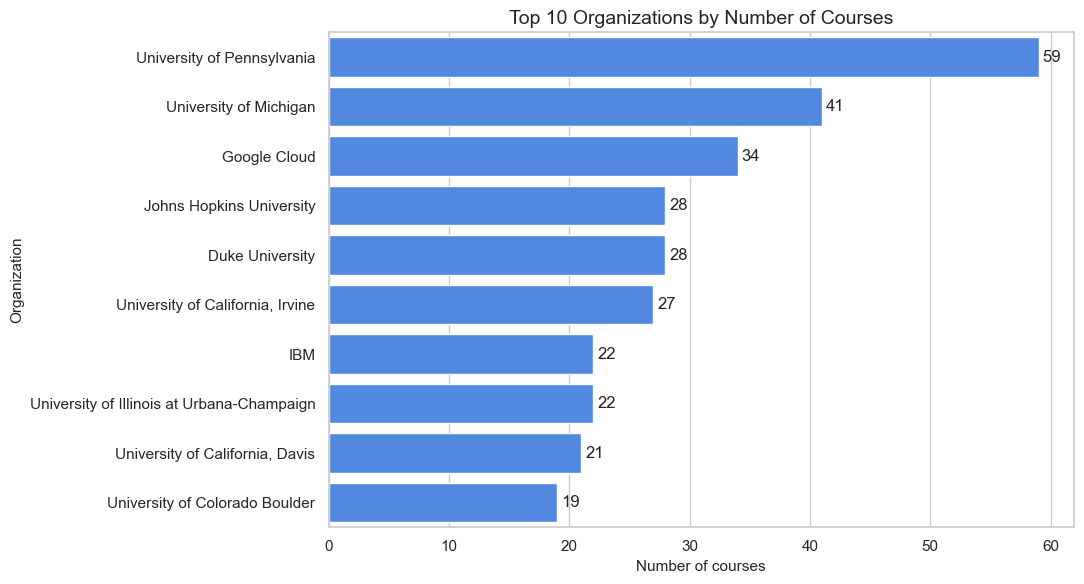

In [25]:
fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=top_organizations,
    y="organization",
    x="course_count",
    color="#3b82f6",
    ax=ax,
)

ax.set_title("Top 10 Organizations by Number of Courses")
ax.set_xlabel("Number of courses")
ax.set_ylabel("Organization")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
fig.savefig(CHART_OUTPUT_DIR / "top_organizations_by_course_count.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight:** University of Pennsylvania leads with 59 courses, followed by University of Michigan with 41 and Google Cloud with 34. This tells us the dataset is not evenly spread across organizations; some providers appear much more often than others.

### Chart 2: Course Count by Certificate Type

This bar chart shows how the dataset is divided across certificate types. This matters because later comparisons can be affected if one group is much larger than another.

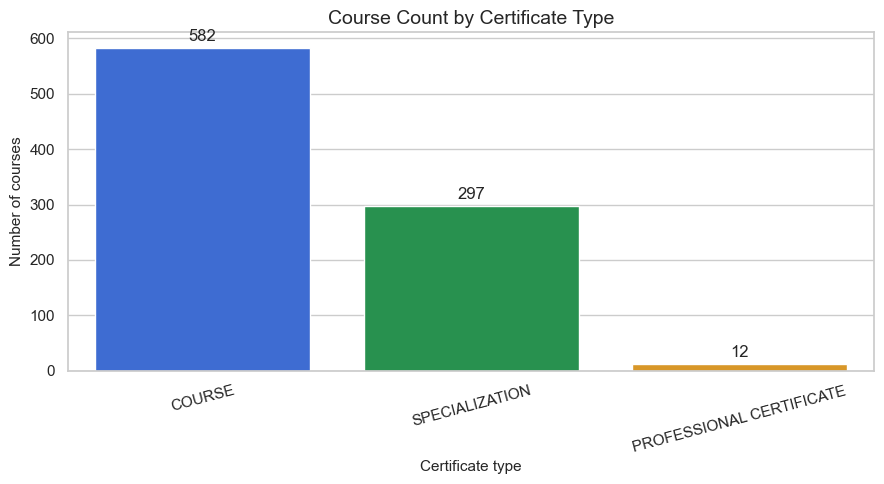

In [26]:
certificate_counts = (
    cleaned_courses["certificate_type"]
    .value_counts()
    .rename_axis("certificate_type")
    .reset_index(name="course_count")
)

fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=certificate_counts,
    x="certificate_type",
    y="course_count",
    hue="certificate_type",
    palette=["#2563eb", "#16a34a", "#f59e0b"],
    legend=False,
    ax=ax,
)

ax.set_title("Course Count by Certificate Type")
ax.set_xlabel("Certificate type")
ax.set_ylabel("Number of courses")
ax.tick_params(axis="x", rotation=15)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
fig.savefig(CHART_OUTPUT_DIR / "course_count_by_certificate_type.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight:** Regular courses dominate the dataset with 582 records. Specializations have 297 records, while professional certificates have only 12. Because professional certificates are a very small group, we should avoid overclaiming from that category.

### Chart 3: Rating Distribution

A histogram shows the shape of one numeric column. Here it helps us see whether ratings are spread out or concentrated in a narrow range.

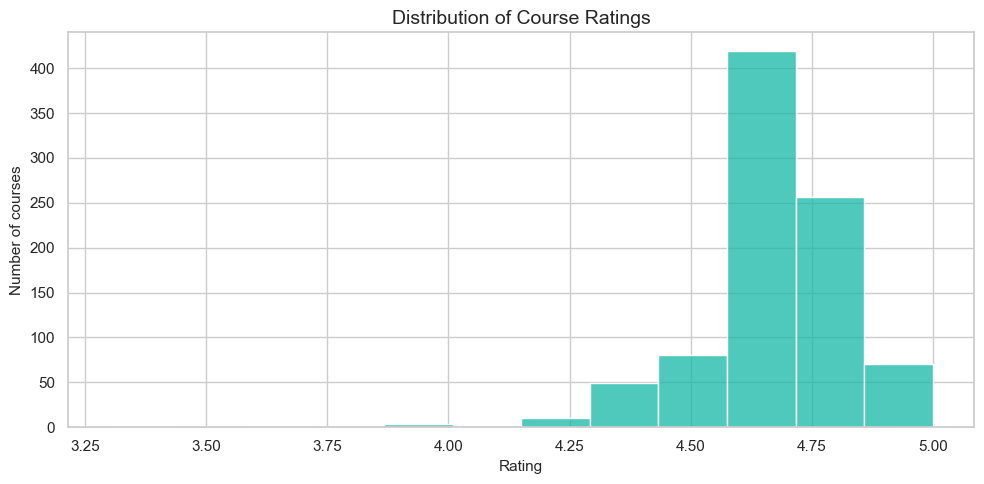

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=cleaned_courses,
    x="rating",
    bins=12,
    color="#14b8a6",
    edgecolor="white",
    ax=ax,
)

ax.set_title("Distribution of Course Ratings")
ax.set_xlabel("Rating")
ax.set_ylabel("Number of courses")

plt.tight_layout()
fig.savefig(CHART_OUTPUT_DIR / "rating_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight:** Ratings are tightly concentrated at the high end of the scale. The dataset's ratings range from 3.3 to 5.0, but most courses are rated above 4.5. This means rating differences are small, so we should interpret rating comparisons carefully.

### Chart 4: Ratings by Difficulty Level

A boxplot compares the spread of ratings across difficulty groups. This is better than only comparing averages because it shows medians, ranges, and possible outliers.

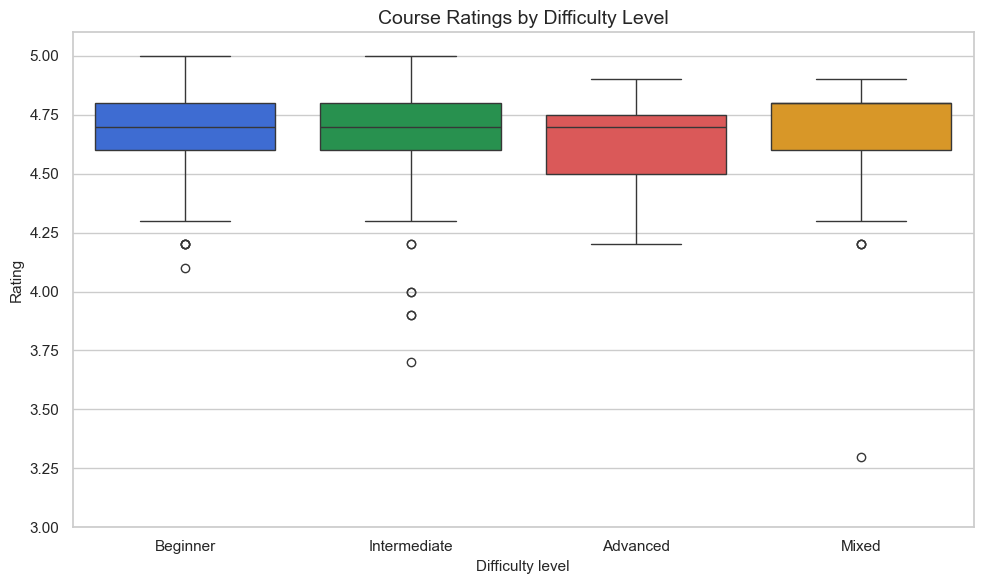

In [28]:
difficulty_order = ["Beginner", "Intermediate", "Advanced", "Mixed"]

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=cleaned_courses,
    x="difficulty",
    y="rating",
    order=difficulty_order,
    hue="difficulty",
    palette=["#2563eb", "#16a34a", "#f59e0b", "#ef4444"],
    legend=False,
    ax=ax,
)

ax.set_title("Course Ratings by Difficulty Level")
ax.set_xlabel("Difficulty level")
ax.set_ylabel("Rating")
ax.set_ylim(3.0, 5.1)

plt.tight_layout()
fig.savefig(CHART_OUTPUT_DIR / "ratings_by_difficulty.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight:** Ratings are high across all difficulty levels. Mixed courses have the highest average rating at 4.709, but the chart also shows that all groups are clustered near the top of the rating scale.

### Chart 5: Ratings by Certificate Type

This boxplot compares rating distributions for courses, specializations, and professional certificates.

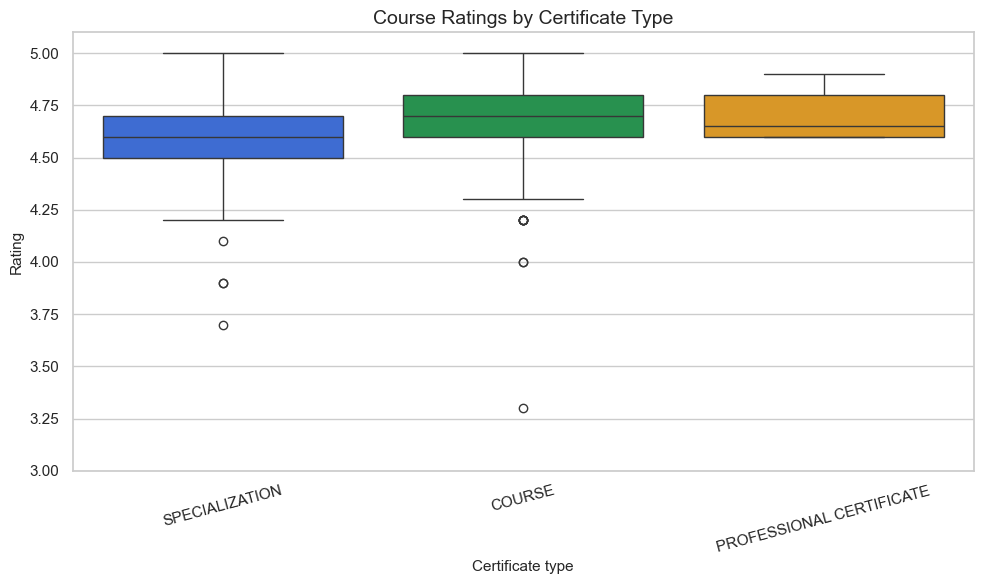

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=cleaned_courses,
    x="certificate_type",
    y="rating",
    hue="certificate_type",
    palette=["#2563eb", "#16a34a", "#f59e0b"],
    legend=False,
    ax=ax,
)

ax.set_title("Course Ratings by Certificate Type")
ax.set_xlabel("Certificate type")
ax.set_ylabel("Rating")
ax.set_ylim(3.0, 5.1)
ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
fig.savefig(CHART_OUTPUT_DIR / "ratings_by_certificate_type.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight:** Regular courses have the highest average rating at 4.707. Specializations have a lower average rating at 4.618. Professional certificates look strong, but there are only 12 records, so the sample size is small.

### Chart 6: Rating vs Enrollment

A scatterplot is useful when we compare two numeric columns. Here each dot is one course. This lets us see whether higher ratings usually come with higher enrollment.

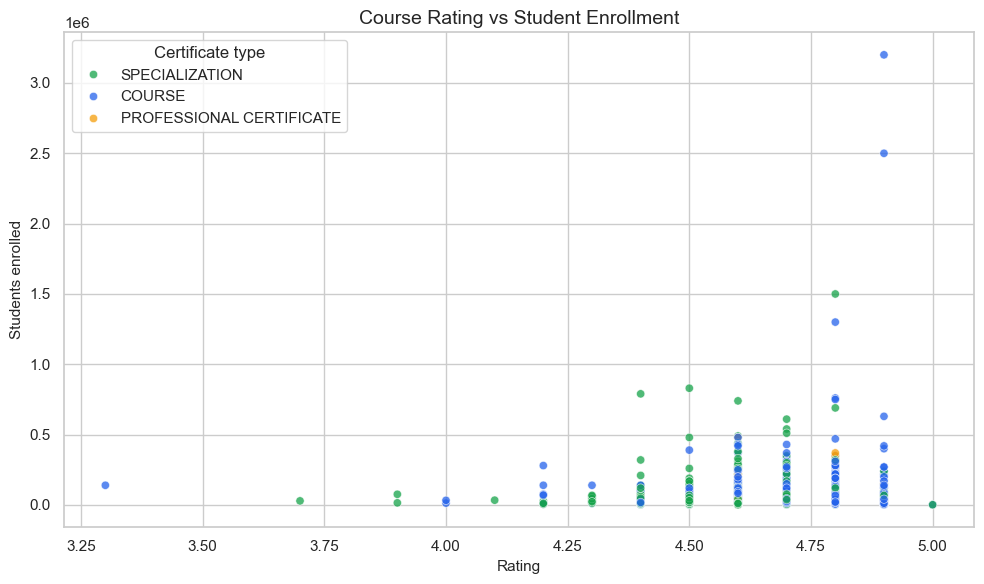

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=cleaned_courses,
    x="rating",
    y="students_enrolled",
    hue="certificate_type",
    palette={
        "COURSE": "#2563eb",
        "SPECIALIZATION": "#16a34a",
        "PROFESSIONAL CERTIFICATE": "#f59e0b",
    },
    alpha=0.75,
    ax=ax,
)

ax.set_title("Course Rating vs Student Enrollment")
ax.set_xlabel("Rating")
ax.set_ylabel("Students enrolled")
ax.legend(title="Certificate type")

plt.tight_layout()
fig.savefig(CHART_OUTPUT_DIR / "rating_vs_enrollment.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight:** The scatterplot supports the correlation result from Phase 3. The points do not form a strong upward pattern, and the correlation is only 0.0711. Some courses have very high enrollment, but high enrollment is not explained by rating alone.

### Phase 4 Visualization Summary

The charts make the main patterns easier to present:

- A small group of organizations contributes many courses.
- Regular courses are the largest certificate category.
- Ratings are generally high and tightly grouped.
- Rating differences between groups exist, but they are not very large.
- Enrollment has large outliers, especially very popular courses with millions of students.
- Rating alone does not explain enrollment.